In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
import math
from pathlib import Path

In [12]:
classes = sorted([d.name for d in os.scandir("dataset") if d.is_dir()])
classes

['angry',
 'confused',
 'cross',
 'flabbergasted',
 'happy',
 'heart',
 'question',
 'sad',
 'tick']

In [13]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 5, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(5, 5, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(5, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(14*14*16, 100),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(100, num_classes)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = out.view(out.shape[0], -1)
        out = self.fc(out)
        return out

In [14]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = Net(num_classes=len(classes))

old_sd = torch.load("weights.pth", map_location="cpu", weights_only=True)
new_sd = model.state_dict()

for key in new_sd:
    if key in old_sd and old_sd[key].shape == new_sd[key].shape:
        new_sd[key] = old_sd[key]
        print(f"  loaded {key}")
    elif key in old_sd:
        print(f"  skipped {key}: shape mismatch old={old_sd[key].shape} new={new_sd[key].shape}")
    else:
        print(f"  init {key} randomly (not in old weights)")

model.load_state_dict(new_sd)
model = model.to(device)
print("Model ready")

Using device: mps
  loaded layer1.0.weight
  loaded layer1.0.bias
  loaded layer1.2.weight
  loaded layer1.2.bias
  loaded layer1.5.weight
  loaded layer1.5.bias
  loaded layer1.7.weight
  loaded layer1.7.bias
  loaded layer1.10.weight
  loaded layer1.10.bias
  skipped fc.0.weight: shape mismatch old=torch.Size([100, 784]) new=torch.Size([100, 3136])
  loaded fc.0.bias
  skipped fc.3.weight: shape mismatch old=torch.Size([20, 100]) new=torch.Size([9, 100])
  skipped fc.3.bias: shape mismatch old=torch.Size([20]) new=torch.Size([9])
Model ready


In [15]:
class DrawingDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        self.classes = sorted([d.name for d in os.scandir(root) if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        return img, label

class SubsetWithTransform(torch.utils.data.Subset):
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __getitems__(self, indices):
        return [self.__getitem__(idx) for idx in indices]

base_transform = transforms.Compose([
    transforms.Resize((56, 56)),
    transforms.ToTensor()
])

train_transform = transforms.Compose([
    transforms.Resize((56, 56)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor()
])

dataset = DrawingDataset("dataset")
print(f"{len(dataset)} images across {len(dataset.classes)} classes: {dataset.classes}")

1080 images across 9 classes: ['angry', 'confused', 'cross', 'flabbergasted', 'happy', 'heart', 'question', 'sad', 'tick']


In [16]:
val_frac = 0.1
val_size = int(len(dataset) * val_frac)
train_size = len(dataset) - val_size

indices = list(range(len(dataset)))
train_idx, val_idx = random_split(indices, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

train_ds = SubsetWithTransform(dataset, train_idx, train_transform)
val_ds = SubsetWithTransform(dataset, val_idx, base_transform)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 972, Val: 108


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [18]:
epochs = 100

for epoch in range(1, epochs + 1):
    current_lr = optimizer.param_groups[0]['lr']

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total * 100
    val_acc = val_correct / val_total * 100
    print(f"Epoch {epoch:2d}/{epochs}  |  "
          f"LR: {current_lr:.2e}  |  "
          f"Train loss: {train_loss/train_total:.4f}  acc: {train_acc:.1f}%  |  "
          f"Val loss: {val_loss/val_total:.4f}  acc: {val_acc:.1f}%")
    scheduler.step(val_loss)

print("Done training!")

Epoch  1/100  |  LR: 2.00e-03  |  Train loss: 1.9974  acc: 26.9%  |  Val loss: 1.6298  acc: 39.8%
Epoch  2/100  |  LR: 2.00e-03  |  Train loss: 1.5985  acc: 38.1%  |  Val loss: 1.3892  acc: 52.8%
Epoch  3/100  |  LR: 2.00e-03  |  Train loss: 1.4227  acc: 44.9%  |  Val loss: 1.3779  acc: 49.1%
Epoch  4/100  |  LR: 2.00e-03  |  Train loss: 1.2971  acc: 48.3%  |  Val loss: 1.1738  acc: 51.9%
Epoch  5/100  |  LR: 2.00e-03  |  Train loss: 1.2238  acc: 49.9%  |  Val loss: 1.1681  acc: 53.7%
Epoch  6/100  |  LR: 2.00e-03  |  Train loss: 1.1764  acc: 55.6%  |  Val loss: 1.0636  acc: 53.7%
Epoch  7/100  |  LR: 2.00e-03  |  Train loss: 1.0646  acc: 59.0%  |  Val loss: 1.0272  acc: 53.7%
Epoch  8/100  |  LR: 2.00e-03  |  Train loss: 1.0183  acc: 56.9%  |  Val loss: 1.0348  acc: 58.3%
Epoch  9/100  |  LR: 2.00e-03  |  Train loss: 0.9417  acc: 62.9%  |  Val loss: 0.9038  acc: 61.1%
Epoch 10/100  |  LR: 2.00e-03  |  Train loss: 0.9666  acc: 60.7%  |  Val loss: 1.0604  acc: 55.6%
Epoch 11/100  |  LR:

NOTE: Best training run yields 94% training accuracy, 90% validation ... On avg we get about 85% validation accuracy (which is kinda okay ig)

In [ ]:
torch.save(model.state_dict(), "weights_retrained.pth")
print("Saved weights_retrained.pth")

Saved retrained.pth


In [ ]:
model.load_state_dict(torch.load("weights_retrained.pth"))

<All keys matched successfully>

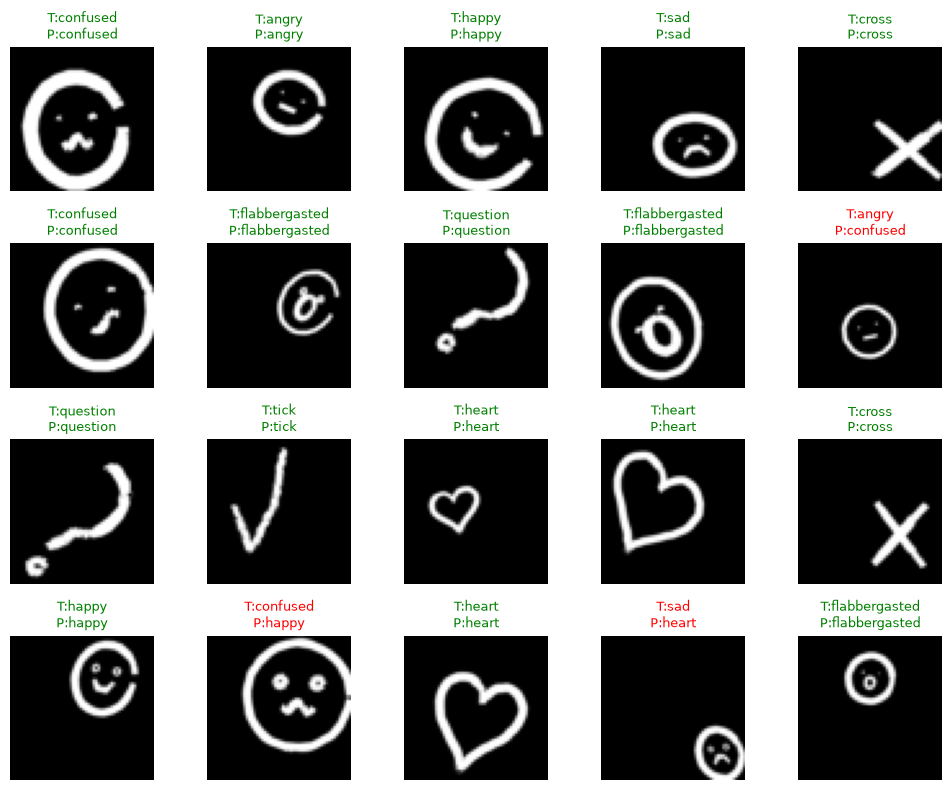

In [11]:
import matplotlib.pyplot as plt

model.eval()
num_samples = 20
cols = 5
rows = math.ceil(num_samples / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

with torch.no_grad():
    for i in range(num_samples):
        img, label = val_ds[i]
        out = model(img.unsqueeze(0).to(device))
        pred = out.argmax(1).item()
        true_name = dataset.classes[label]
        pred_name = dataset.classes[pred]
        color = "green" if pred == label else "red"
        axes[i].imshow(img.squeeze(), cmap="gray")
        axes[i].set_title(f"T:{true_name}\nP:{pred_name}", fontsize=9, color=color)
        axes[i].axis("off")

for i in range(num_samples, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()